## Model Training On Synthetic Data

In [2]:
# Import modules
import pandas as pd
import numpy as np

### Load Dataset

In [3]:
transactions_data_train = pd.read_csv("data/train.csv")
print(transactions_data_train.head())

       amount  hour  day_of_week merchant_category  is_fraud
0  214.056124    10            2            retail         0
1  470.044641    14            1           grocery         0
2   59.567221     9            4           grocery         0
3   28.190464    21            0            retail         0
4   45.258306    16            3           grocery         0


## Data Preparation 

### One Hot Encoding

Before trainng any machine learning model, the data has to be in the proper format for the task at hand. Machine learning models work only with numerical data and don't now what to do with text data. Here the merchant category feature is encoded using One Hot Encoding.

In [4]:
transactions_data_train = pd.get_dummies(transactions_data_train, columns=["merchant_category"], dtype="int")
print(transactions_data_train.head())

       amount  hour  day_of_week  is_fraud  merchant_category_grocery  \
0  214.056124    10            2         0                          0   
1  470.044641    14            1         0                          1   
2   59.567221     9            4         0                          1   
3   28.190464    21            0         0                          0   
4   45.258306    16            3         0                          1   

   merchant_category_online  merchant_category_restaurant  \
0                         0                             0   
1                         0                             0   
2                         0                             0   
3                         0                             0   
4                         0                             0   

   merchant_category_retail  merchant_category_travel  
0                         1                         0  
1                         0                         0  
2                         

### Train and Test Splits

Before trainig any machine learnig model the data should be split into training and testing sets. This is done so we can use one part of the data to train the model and the other part which remains hidden during training is for testing the model's performance on unseen data. A good rule of thumb is to use 80% of the data for traiing and 20% of the data for testing or validation of the model. Here `train.csv` is spit into 80% traing data and 20% validation data for hyperparameter tuning and evaluation. `Test.csv` will be used for the final evaluation of the model.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Predictor features
X = transactions_data_train.drop("is_fraud", axis=1)

# Target labels - fraud, not fraud
y = transactions_data_train["is_fraud"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Standardizing Numerical Features

Some machine learning models require numerical features to be on the same scale inorder to make proper predictions. As noted during exploration of the data some of the numerical features are on vastly different scales and are in need of standardization. Standard Scaler is used here to scale all of the numerical features to have a mean of zero and a unit of variance. This is done after train-test splitting to prevent __data leakage__.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Model Building

It's time to try out a few models and see how they perform on the task. Let's start simple and increase model complexity as we go. Bellow a few popular machine learning classification algorithms are imported 

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

### Evaluation Metrics

Given the imbalanced dataset, the suitable metric for evaluating the models is __average precision score__

__AP__ summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$$ AP = \sum_{n} (R_n - R_{n-1})P_n $$

where $ P_n $ and $ R_n $ are the precision and recall at the nth threshold. This implementation is not interpolated and is different from computing the area under the precision-recall curve with the trapezoidal rule, which uses linear interpolation and can be too optimistic.

In [8]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, precision_recall_curve

### Logistic Regression

Bellow the model was trained with default prameters and achived 49% on the training set and 62% on the validation set which is promissing. Hyperpamrameter tuning may improve model performance if applied later on.

In [9]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_proba_train = log_reg.predict_proba(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Train set score: {train_score}")

y_proba_val = log_reg.predict_proba(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Train set score: 0.49058320948694656
Validation set score: 0.6221484086944218


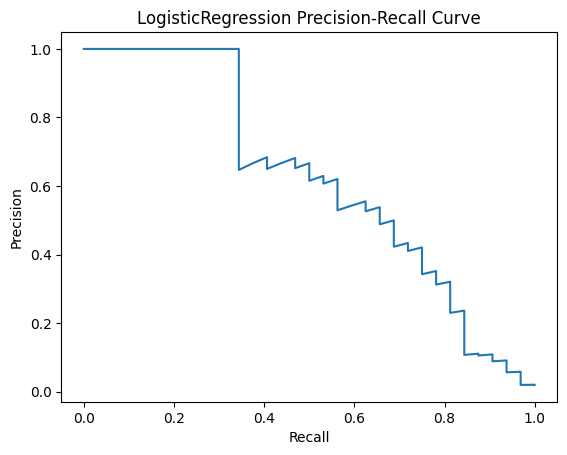

In [10]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_val, y_proba_val[:, 1], pos_label=1)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LogisticRegression Precision-Recall Curve")
plt.show()

### K-Nearest Neighbors Classifier

Bellow the model was trained using default parameters and achived a score of 62% on the training set and 36% on the validation set which may be a sign of overfitting to the trainng set. Adjusting the `n_neighbors` hyperparmeter may increase model performance. 

In [11]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_scaled, y_train)

y_proba_train = knn_clf.predict_proba(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Training set score: {train_score}")

y_proba_val = knn_clf.predict_proba(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Training set score: 0.6268993100825728
Validation set score: 0.3610931647940075


### Linear Support Vector Classifier

Bellow the model was trained using defaut parameters and achived a score of 46% on the training set and 56% on the validation set which is promissing. The slightly lower training score is caused by the fact that `LinearSVC` uses `L2` regulariztion by default which makes the model slightly underfit on the training set.

In [12]:
linear_svc = LinearSVC(random_state=42)
linear_svc.fit(X_train_scaled, y_train)

y_proba_train = linear_svc.decision_function(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train)

print(f"Training set score: {train_score}")

y_proba_val = linear_svc.decision_function(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val)

print(f"Validation set score: {val_score}")

Training set score: 0.46565126621591485
Validation set score: 0.5642262803019147


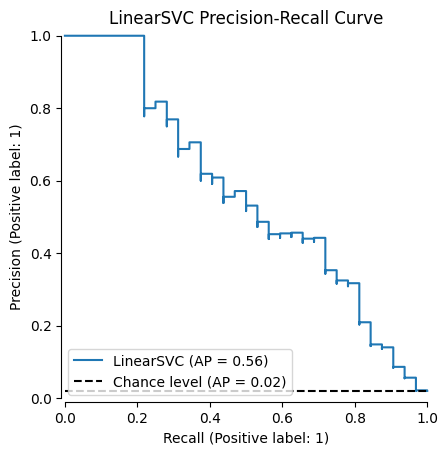

In [14]:
display = PrecisionRecallDisplay.from_predictions(
    y_val, 
    y_proba_val, 
    name="LinearSVC", 
    plot_chance_level=True, 
    despine=True
)

_ = display.ax_.set_title("LinearSVC Precision-Recall Curve")

### Random Forest Classifier

Bellow the model was trained using default parameters and achived a score of 100% on the training set and 50% on the validation set which clearly indicates that it's overfitting on the training set. Lowering model complexity during hyperparameter tuning may solve this issue

In [18]:
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)

y_proba_train = forest_clf.predict_proba(X_train)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Training set score: {train_score}")

y_proba_val = forest_clf.predict_proba(X_val)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Training set score: 1.0
Validation set score: 0.5069880357401684
